In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts 

In [ ]:
df1 = pd.read_csv('../Data/newvulturedata.csv', low_memory=False)

In [4]:
df1

,event-id,timestamp,location-long,location-lat,gps:vdop,ground-speed,heading,height-above-ellipsoid,height-raw,location-error-text,...,ECMWF Interim Full Daily SFC-FC Evaporation,ECMWF Interim Full Daily SFC-FC Ice Temperature L1 0-7 cm,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Night,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Day,ECMWF Interim Full Daily SFC-FC Snow Temperature,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation,ECMWF Interim Full Daily SFC-FC 10 Metre Wind Gust,ECMWF Interim Full Daily SFC-FC Sunshine Duration,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation Downwards,ECMWF Interim Full Daily SFC-FC Soil Water Content L1 0-7 cm
0,2165455237,00:00.0,-75.71683,40.36050,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.147555e-03,271.460083,286.471885,295.189129,291.382888,-3750718.376,12.970062,32400.00000,8.954898e+06,0.304947
1,2165455238,00:00.0,-75.72283,40.35550,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.239890e-03,271.459981,286.440183,295.230607,290.607350,-4138569.866,12.344167,34052.74409,9.976523e+06,0.304715
2,2165455239,00:00.0,-75.72233,40.35533,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.336324e-03,271.459880,286.452746,295.229222,289.817859,-4526495.647,11.722474,35704.89981,1.100000e+07,0.304459
3,2165455240,00:00.0,-75.72250,40.35533,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.490000e-04,271.460368,286.561082,295.153483,284.477042,-3588712.040,5.352246,1200.00000,1.080000e+07,0.301806
4,2165455241,00:00.0,-75.72267,40.35550,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.650000e-04,271.460785,286.568959,295.143110,284.171710,-3898147.400,4.947947,1800.00000,1.180000e+07,0.301560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179984,2165850299,00:00.0,-72.98967,5.70900,NaN,0.0,0.0,NaN,2850,NaN,...,-4.006496e-03,271.460103,279.176820,298.715233,292.510556,-2848983.073,6.642973,33678.93984,1.410000e+07,0.345117
179985,2165850300,00:00.0,-72.98967,5.70900,NaN,0.0,0.0,NaN,2840,NaN,...,-4.049190e-03,271.460022,279.174262,298.711315,291.393140,-3047442.173,5.903010,34318.40976,1.540000e+07,0.345435
179986,2165850301,00:00.0,-72.98967,5.70917,NaN,0.0,0.0,NaN,2840,NaN,...,-2.699154e-03,271.460022,279.174657,298.715971,290.784554,-2209954.478,5.249158,22878.89373,1.140000e+07,0.345680
179987,2165850302,00:00.0,-72.98950,5.70900,NaN,0.0,0.0,NaN,2820,NaN,...,-1.349113e-03,271.460022,279.177693,298.701199,290.177226,-1372447.473,4.595964,11439.44192,7.534932e+06,0.345918


In [5]:
df2 = df1[(df1['individual-local-identifier'] == 'Rosalie')]

In [6]:
df2 # filtered for rosalie

,event-id,timestamp,location-long,location-lat,gps:vdop,ground-speed,heading,height-above-ellipsoid,height-raw,location-error-text,...,ECMWF Interim Full Daily SFC-FC Evaporation,ECMWF Interim Full Daily SFC-FC Ice Temperature L1 0-7 cm,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Night,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Day,ECMWF Interim Full Daily SFC-FC Snow Temperature,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation,ECMWF Interim Full Daily SFC-FC 10 Metre Wind Gust,ECMWF Interim Full Daily SFC-FC Sunshine Duration,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation Downwards,ECMWF Interim Full Daily SFC-FC Soil Water Content L1 0-7 cm
57176,2165530709,00:00.0,-116.572667,34.051667,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000894,271.460693,277.312211,291.915104,288.017272,-3.525306e+06,12.225116,28293.168220,1.290000e+07,0.191972
57177,2165530710,00:00.0,-116.572667,34.051667,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000620,271.460673,277.320694,291.942490,286.723768,-2.715112e+06,11.661928,20062.112150,9.534786e+06,0.192217
57178,2165530711,00:00.0,-116.572667,34.052000,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000347,271.460653,277.316163,291.952725,285.430244,-1.904902e+06,11.099286,11831.122660,6.187854e+06,0.192467
57179,2165530712,00:00.0,-116.572667,34.051500,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000074,271.460632,277.344172,292.005856,284.136783,-1.094736e+06,10.535173,3600.000000,2.840806e+06,0.192705
57180,2165530713,00:00.0,-116.572667,34.051667,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000078,271.460449,277.346145,292.024647,283.200053,-1.397633e+06,9.328338,3600.000000,3.744538e+06,0.192806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85792,2165559325,00:00.0,-123.392670,46.265830,NaN,0.0,38.0,NaN,120,NaN,...,-0.000471,271.460022,270.037586,283.236868,282.374080,-1.560323e+06,11.867842,3600.000000,1.030000e+07,0.355045
85793,2165559326,00:00.0,-123.392670,46.265830,NaN,0.0,78.0,NaN,142,NaN,...,-0.000313,271.460083,270.018400,283.225988,282.389896,-8.200457e+05,11.278078,1800.000000,7.016052e+06,0.354233
85794,2165559327,00:00.0,-123.392170,46.265670,NaN,0.0,25.0,NaN,104,NaN,...,-0.000454,271.460358,269.957376,283.176722,282.511549,-2.997241e+05,9.959635,5312.026084,7.348319e+06,0.348525
85795,2165559328,00:00.0,-123.402670,46.260170,NaN,0.0,117.0,NaN,103,NaN,...,-0.000659,271.460246,269.479178,283.343632,282.754442,-3.745431e+05,10.788399,8809.338274,8.583768e+06,0.348266


In [7]:
Full = df2[['raptor-workshop:migration-state'] + df2.columns[16:].to_list()].reset_index(drop=True)

In [18]:
Full

,raptor-workshop:migration-state,ECMWF Interim Full Daily SFC-FC Downward UV Radiation at the Surface,ECMWF Interim Full Daily SFC-FC Total Atmospheric Water,NCEP NARR SFC Plant Canopy Surface Water at Surface,ECMWF Interim Full Daily SFC-FC TOA Incident Solar Radiation,ASTER ASTGTM2 Elevation,SEDAC GPW V3 and GRUMP V1 GRUMP 2000 Population Density Adjusted,ECMWF Interim Full Daily SFC-FC Dew Point Temperature (2 m above Ground),ECMWF Interim Full Daily SFC-FC Snow Evaporation,ECMWF Interim Full Daily SFC-FC Water Vapor Concentration,...,ECMWF Interim Full Daily SFC-FC Evaporation,ECMWF Interim Full Daily SFC-FC Ice Temperature L1 0-7 cm,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Night,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Day,ECMWF Interim Full Daily SFC-FC Snow Temperature,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation,ECMWF Interim Full Daily SFC-FC 10 Metre Wind Gust,ECMWF Interim Full Daily SFC-FC Sunshine Duration,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation Downwards,ECMWF Interim Full Daily SFC-FC Soil Water Content L1 0-7 cm
0,4.0,6.413235e+06,9.569087,0.077440,2.930000e+07,779.600125,128.449395,273.331326,1.820000e-08,9.516699,...,-0.000894,271.460693,277.312211,291.915104,288.017272,-3.525306e+06,12.225116,28293.168220,1.290000e+07,0.191972
1,4.0,4.354715e+06,9.333640,0.067418,2.020000e+07,779.600125,128.449395,273.521367,1.450000e-08,9.293301,...,-0.000620,271.460673,277.320694,291.942490,286.723768,-2.715112e+06,11.661928,20062.112150,9.534786e+06,0.192217
2,4.0,2.296138e+06,9.098017,0.057218,1.100000e+07,780.079976,132.207857,273.710155,1.090000e-08,9.069728,...,-0.000347,271.460653,277.316163,291.952725,285.430244,-1.904902e+06,11.099286,11831.122660,6.187854e+06,0.192467
3,4.0,2.376790e+05,8.862874,0.047449,1.905044e+06,778.520264,126.570108,273.902121,7.220000e-09,8.846629,...,-0.000074,271.460632,277.344172,292.005856,284.136783,-1.094736e+06,10.535173,3600.000000,2.840806e+06,0.192705
4,4.0,2.376743e+05,8.959371,0.042706,1.905096e+06,779.600125,128.449395,274.132495,6.980000e-10,8.938823,...,-0.000078,271.460449,277.346145,292.024647,283.200053,-1.397633e+06,9.328338,3600.000000,3.744538e+06,0.192806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28616,4.0,3.029783e+05,16.879060,0.500000,2.012632e+06,165.538032,1.163304,280.765177,-1.440000e-08,16.313923,...,-0.000471,271.460022,270.037586,283.236868,282.374080,-1.560323e+06,11.867842,3600.000000,1.030000e+07,0.355045
28617,4.0,1.537947e+05,15.944844,0.500000,1.212372e+06,165.538032,1.163304,280.670674,-9.310000e-09,15.500738,...,-0.000313,271.460083,270.018400,283.225988,282.389896,-8.200457e+05,11.278078,1800.000000,7.016052e+06,0.354233
28618,4.0,4.802537e+05,13.851796,0.465296,6.443541e+06,166.669088,1.084182,281.657073,2.140000e-08,13.669490,...,-0.000454,271.460358,269.957376,283.176722,282.511549,-2.997241e+05,9.959635,5312.026084,7.348319e+06,0.348525
28619,4.0,8.247962e+05,14.987387,0.474723,9.900644e+06,75.598544,2.055920,281.880452,1.330000e-08,14.743537,...,-0.000659,271.460246,269.479178,283.343632,282.754442,-3.745431e+05,10.788399,8809.338274,8.583768e+06,0.348266


In [8]:
YFull = Full.iloc[:,0]
YFull

0        4.0
1        4.0
2        4.0
3        4.0
4        4.0
        ... 
28616    4.0
28617    4.0
28618    4.0
28619    4.0
28620    4.0
Name: raptor-workshop:migration-state, Length: 28621, dtype: float64

In [9]:
XFull = Full.iloc[:,1:]
XFull

,ECMWF Interim Full Daily SFC-FC Downward UV Radiation at the Surface,ECMWF Interim Full Daily SFC-FC Total Atmospheric Water,NCEP NARR SFC Plant Canopy Surface Water at Surface,ECMWF Interim Full Daily SFC-FC TOA Incident Solar Radiation,ASTER ASTGTM2 Elevation,SEDAC GPW V3 and GRUMP V1 GRUMP 2000 Population Density Adjusted,ECMWF Interim Full Daily SFC-FC Dew Point Temperature (2 m above Ground),ECMWF Interim Full Daily SFC-FC Snow Evaporation,ECMWF Interim Full Daily SFC-FC Water Vapor Concentration,ECMWF Interim Full Daily SFC-FC Snow Albedo,...,ECMWF Interim Full Daily SFC-FC Evaporation,ECMWF Interim Full Daily SFC-FC Ice Temperature L1 0-7 cm,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Night,MODIS Land Surface Temp & Emissivity .05deg 8d Terra Land Surface Temperature Day,ECMWF Interim Full Daily SFC-FC Snow Temperature,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation,ECMWF Interim Full Daily SFC-FC 10 Metre Wind Gust,ECMWF Interim Full Daily SFC-FC Sunshine Duration,ECMWF Interim Full Daily SFC-FC Surface Thermal Radiation Downwards,ECMWF Interim Full Daily SFC-FC Soil Water Content L1 0-7 cm
0,6.413235e+06,9.569087,0.077440,2.930000e+07,779.600125,128.449395,273.331326,1.820000e-08,9.516699,0.849998,...,-0.000894,271.460693,277.312211,291.915104,288.017272,-3.525306e+06,12.225116,28293.168220,1.290000e+07,0.191972
1,4.354715e+06,9.333640,0.067418,2.020000e+07,779.600125,128.449395,273.521367,1.450000e-08,9.293301,0.849998,...,-0.000620,271.460673,277.320694,291.942490,286.723768,-2.715112e+06,11.661928,20062.112150,9.534786e+06,0.192217
2,2.296138e+06,9.098017,0.057218,1.100000e+07,780.079976,132.207857,273.710155,1.090000e-08,9.069728,0.849998,...,-0.000347,271.460653,277.316163,291.952725,285.430244,-1.904902e+06,11.099286,11831.122660,6.187854e+06,0.192467
3,2.376790e+05,8.862874,0.047449,1.905044e+06,778.520264,126.570108,273.902121,7.220000e-09,8.846629,0.849998,...,-0.000074,271.460632,277.344172,292.005856,284.136783,-1.094736e+06,10.535173,3600.000000,2.840806e+06,0.192705
4,2.376743e+05,8.959371,0.042706,1.905096e+06,779.600125,128.449395,274.132495,6.980000e-10,8.938823,0.849998,...,-0.000078,271.460449,277.346145,292.024647,283.200053,-1.397633e+06,9.328338,3600.000000,3.744538e+06,0.192806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28616,3.029783e+05,16.879060,0.500000,2.012632e+06,165.538032,1.163304,280.765177,-1.440000e-08,16.313923,0.849998,...,-0.000471,271.460022,270.037586,283.236868,282.374080,-1.560323e+06,11.867842,3600.000000,1.030000e+07,0.355045
28617,1.537947e+05,15.944844,0.500000,1.212372e+06,165.538032,1.163304,280.670674,-9.310000e-09,15.500738,0.849998,...,-0.000313,271.460083,270.018400,283.225988,282.389896,-8.200457e+05,11.278078,1800.000000,7.016052e+06,0.354233
28618,4.802537e+05,13.851796,0.465296,6.443541e+06,166.669088,1.084182,281.657073,2.140000e-08,13.669490,0.849998,...,-0.000454,271.460358,269.957376,283.176722,282.511549,-2.997241e+05,9.959635,5312.026084,7.348319e+06,0.348525
28619,8.247962e+05,14.987387,0.474723,9.900644e+06,75.598544,2.055920,281.880452,1.330000e-08,14.743537,0.849998,...,-0.000659,271.460246,269.479178,283.343632,282.754442,-3.745431e+05,10.788399,8809.338274,8.583768e+06,0.348266


In [10]:
fH = 24 #forecast horizon


XFull2 = XFull[0:len(XFull)-fH]
YFull2 = YFull[fH:len(YFull)]
# for forecasting



In [11]:
X_train,X_test,y_train,y_test = tts(XFull,YFull,test_size=0.2, shuffle=False) # remove shuffle

In [12]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train2 = imputer.fit_transform(X_train)
X_test2 = imputer.transform(X_test)

In [19]:
for col in Full.columns:
    try:
      print(col, 'correlation coefficient: ', np.corrcoef(Full[col], Full['raptor-workshop:migration-state'])[0][1] )
    except:
        print(col)
        

raptor-workshop:migration-state correlation coefficient:  1.0
ECMWF Interim Full Daily SFC-FC Downward UV Radiation at the Surface correlation coefficient:  -0.07180520532687126
ECMWF Interim Full Daily SFC-FC Total Atmospheric Water correlation coefficient:  -0.46191178883245554
NCEP NARR SFC Plant Canopy Surface Water at Surface correlation coefficient:  nan
ECMWF Interim Full Daily SFC-FC TOA Incident Solar Radiation correlation coefficient:  -0.1575517224668778
ASTER ASTGTM2 Elevation correlation coefficient:  0.8175330289057177
SEDAC GPW V3 and GRUMP V1 GRUMP 2000 Population Density Adjusted correlation coefficient:  nan
ECMWF Interim Full Daily SFC-FC Dew Point Temperature (2 m above Ground) correlation coefficient:  -0.38933904409070635
ECMWF Interim Full Daily SFC-FC Snow Evaporation correlation coefficient:  -0.026519535043390403
ECMWF Interim Full Daily SFC-FC Water Vapor Concentration correlation coefficient:  -0.4630896924869317
ECMWF Interim Full Daily SFC-FC Snow Albedo c

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train3 = scaler.fit_transform(X_train2)
X_test3 = scaler.transform(X_test2)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay as CMD

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)
                     ])

clf.fit(X_train,y_train.values.ravel())


preds = clf.predict(X_test)
output = pd.DataFrame({'Id': X_test.index,
                       'Predicted': preds,
                       'Actual': y_test.values.ravel()})

output



KNN
Accuracy: 0.9813
F1 Score (macro): 0.9507


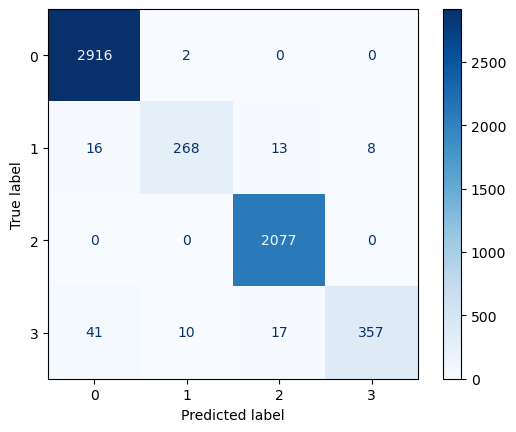


Random Forest
Accuracy: 0.9960
F1 Score (macro): 0.9911


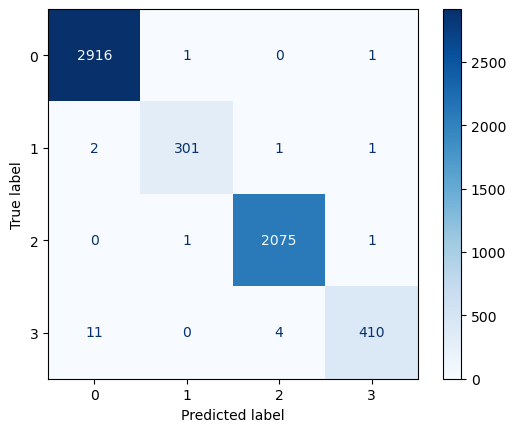


Gradient Boosting
Accuracy: 0.9939
F1 Score (macro): 0.9847


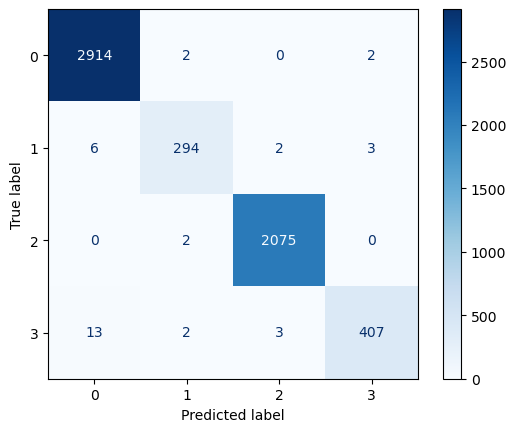


Logistic Regression
Accuracy: 0.9406
F1 Score (macro): 0.8068


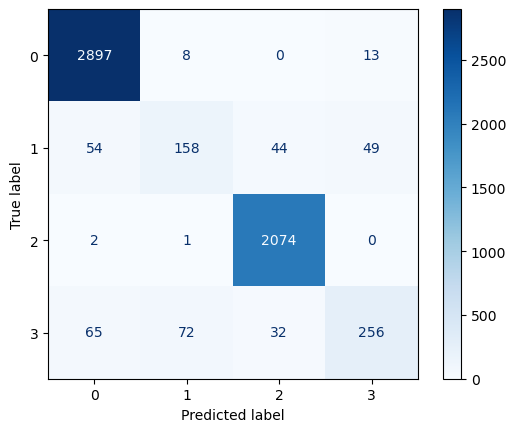


AdaBoost
Accuracy: 0.9661
F1 Score (macro): 0.9177


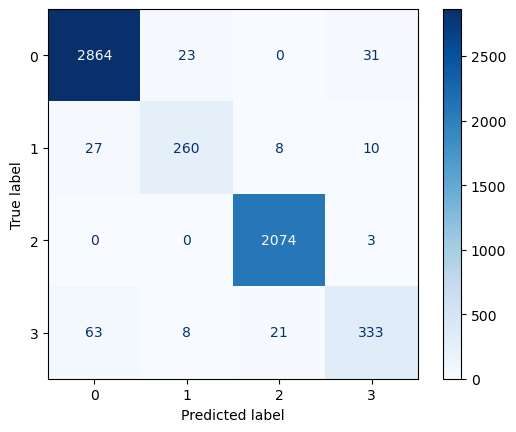


Support Vector Classifier
Accuracy: 0.9783
F1 Score (macro): 0.9397


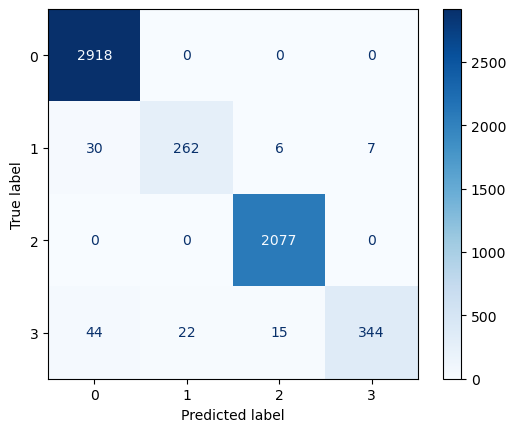

In [ ]:
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Classifier": SVC()
}

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train3, y_train)
    y_pred = model.predict(X_test3)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

    cm = confusion_matrix(y_test,y_pred)
    disp = CMD(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.show()

